<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/04_Building_Models_with_Distance_Metrics_and_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Building Models with Distance Metrics and Nearest Neighbors**
This notebook covers the foundational concepts and practical implementations of K-Nearest Neighbors based on the core literature for my thesis methodology:

1. Introduction to distance metrics
2. Understanding KNNs
3. Distance metrics overview
4. Hyperparameter tuning in KNN
5. Evaluating KNN performance

# **1. Introduction to Distance Metrics**
In machine learning, understanding how similar or dissimilar data points are is central to classification and clustering tasks. The distance between points in a feature space is mathematically measured using distance metrics. The three foundational ways to measure this distance include:
* **Euclidean distance:** The standard, straight-line distance between two points in an n-dimensional space.
* **Manhattan distance:** A metric that measures the sum of absolute differences, moving only along orthogonal (horizontal and vertical) directions, much like navigating a city grid. It is often more robust to outliers.
* **Minkowski distance:** A generalized metric that adjusts a parameter, $p$, to aggregate distances, effectively encompassing both Euclidean and Manhattan methods.

# **2. Understanding KNNs**
The K-Nearest Neighbors (KNN) algorithm serves as a foundational supervised learning approach utilized in both classification and regression analyses. Its underlying premise relies heavily on spatial proximity within a defined feature space. Specifically, upon the introduction of a novel data point, we can infer its characteristics by examining the known data points situated nearest to it, calculated via a specific distance metric.

## **Getting ready**
To begin, we utilize the famous Iris dataset from scikit-learn and separate it into training and testing sets.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

## **How to do it**
Implementation in scikit-learn is highly streamlined. We define the classifier, fit it to the training data, and generate predictions.

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


## **How it works & Distance metrics variations**
The algorithm relies on three fundamental steps:
1. **Choosing k:** The $k$ parameter is the number of neighbors considered. A small $k$ is sensitive to noise, while a large $k$ smooths predictions but might miss local patterns.
2. **Calculating distances:** It uses a metric (like Euclidean or Manhattan) to find the closest points.
3. **Voting mechanism:** In classification, the new point is assigned the label held by the majority of its $k$ nearest neighbors.

Selecting the optimal $k$ often involves strategies like cross-validation to minimize error or the "elbow method" to visually identify where increasing $k$ yields diminishing returns. Furthermore, while Euclidean is standard, experimenting with other metrics (e.g., Hamming for categorical data) can yield better results.

# **3. Distance Metrics Overview**
In machine learning algorithms such as K-Nearest Neighbors (KNN), the selection of an appropriate distance metric is paramount, as it fundamentally dictates how the model quantifies the similarity or divergence between individual data points. Relying solely on the conventional Euclidean distance can be strategically limiting; different datasets possess unique structural properties that can significantly sway classification accuracy and cluster formation depending on the chosen metric. Therefore, developing a comprehensive understanding of various distance measurements is crucial for robust model development. This forthcoming section will empirically demonstrate how the efficacy of different distance metrics fluctuates in response to the specific characteristics and distributions of diverse datasets.

## **Getting ready**
To observe this, we can generate synthetic datasets (a noisy circular dataset and a checkerboard/moons dataset) and evaluate different metrics.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

n_samples = 300
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024
)

## **How to do it**
To compare various distance metrics, we’ll cycle through each one and build two KNN classifiers with
it on our datasets, then visualize the dataset along with the performance metric, which is accuracy:

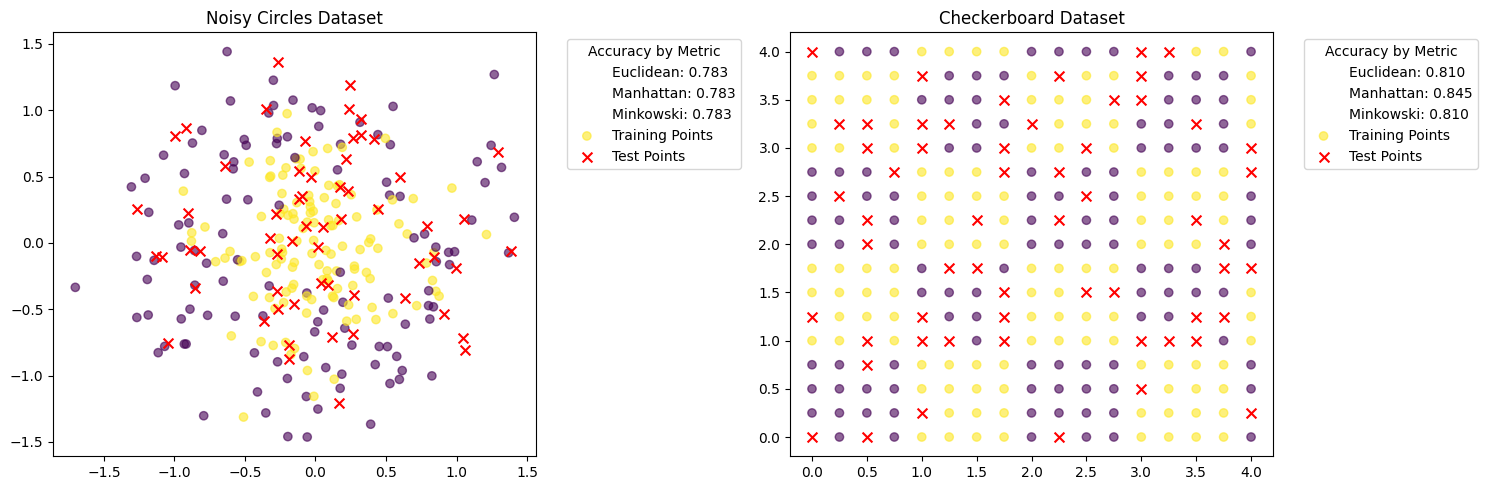

In [4]:
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)

    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

scatter1_train = ax1.scatter(
    X_circles_train[:, 0], X_circles_train[:, 1],
    c=y_circles_train, cmap='viridis',
    alpha=0.6, label='Training Points'
)
scatter1_test = ax1.scatter(
    X_circles_test[:, 0], X_circles_test[:, 1],
    color='red', marker='x', s=50,
    label='Test Points'
)
ax1.set_title('Noisy Circles Dataset')

lines1 = [plt.Line2D([0], [0], color='white')
          for _ in metrics]
legend_text1 = [
    f"Euclidean: {results['circles']['euclidean']:.3f}",
    f"Manhattan: {results['circles']['manhattan']:.3f}",
    f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(
    lines1 + [scatter1_train, scatter1_test],
    legend_text1 + ['Training Points', 'Test Points'],
    title='Accuracy by Metric',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

scatter2_train = ax2.scatter(
    X_moons_train[:, 0], X_moons_train[:, 1],
    c=y_moons_train, cmap='viridis',
    alpha=0.6, label='Training Points'
)
scatter2_test = ax2.scatter(
    X_moons_test[:, 0], X_moons_test[:, 1],
    color='red', marker='x', s=50,
    label='Test Points'
)
ax2.set_title('Checkerboard Dataset')

lines2 = [plt.Line2D([0], [0], color='white')
          for _ in metrics]
legend_text2 = [
    f"Euclidean: {results['moons']['euclidean']:.3f}",
    f"Manhattan: {results['moons']['manhattan']:.3f}",
    f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(
    lines2 + [scatter2_train, scatter2_test],
    legend_text2 + ['Training Points', 'Test Points'],
    title='Accuracy by Metric',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()

## **How it works & Impact on model performance**
* **Euclidean** calculates straight-line distance, is sensitive to outliers, and works best when features are scaled similarly.
* **Manhattan** measures the sum of absolute differences and is less sensitive to outliers compared to Euclidean distance.
* **Minkowski** is a generalization of both; adjusting the $p$ parameter switches between these metrics ($p=1$ for Manhattan and $p=2$ for Euclidean).

Because metrics like Euclidean are influenced by magnitude, standardization or normalization is crucial before applying KNN. In high-dimensional spaces, distances can become less meaningful due to the curse of dimensionality.

# **4. Hyperparameter Tuning in KNN**
Optimizing a machine learning model inherently requires rigorous hyperparameter tuning, which necessitates a clear, conceptual distinction between model parameters and hyperparameters. While parameters are the internal variables that the model autonomously extracts from the training data to map inputs to outputs—such as the slope $m$ and intercept $b$ in a standard linear regression equation, $y = mx + b$—hyperparameters are the overarching, user-defined configurations that govern the learning process itself. Essentially, hyperparameters dictate how the model should learn the optimal parameters. To maximize a model's predictive capabilities, it is essential to systematically identify the ideal combination of these settings; thus, this analysis will explore the application of two distinct search methodologies designed to efficiently navigate the hyperparameter space and achieve peak model performance.

## **Getting ready & How to do it**
We can use Grid Search to find the optimal combination of neighbors, weight logic, and distance metrics.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668


## **How it works & Randomized search**
Grid Search exhaustively searches through a specified parameter grid to find the best combination based on model performance. By coupling this with cross-validation (evaluating on different subsets of data), we prevent overfitting and secure a more reliable estimate of model performance. For larger parameter spaces, RandomizedSearchCV samples from parameter distributions randomly, which can save time while yielding good results.

# **5. Evaluating KNN Performance**
Evaluating the performance of KNN models is essential for understanding how well the model makes predictions and where it may need improvement. This recipe will cover various techniques for assessing KNN performance, including confusion matrices, precision, recall, and F1-scores.

## **Getting ready & How to do it**
We utilize learning curves, confusion matrices, and classification reports.

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9916666666666668
Standard deviation: 0.016666666666666653


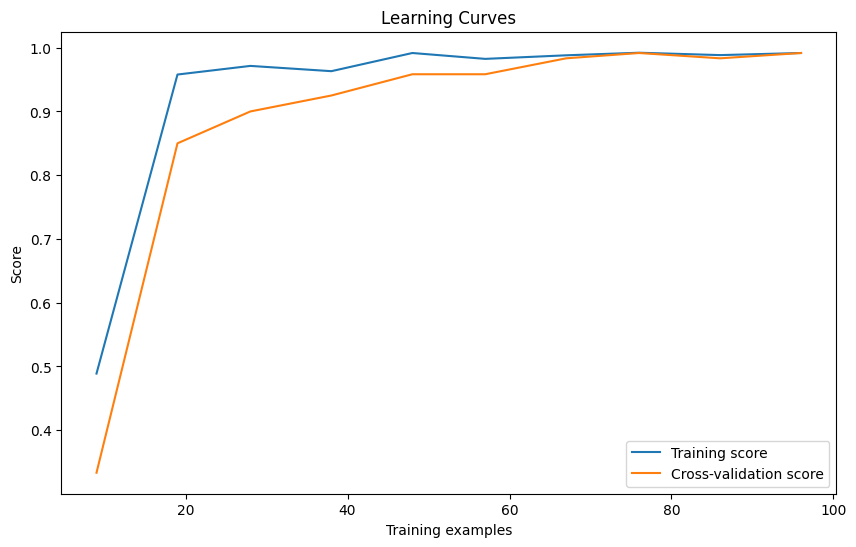

In [6]:
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5
)

plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    label='Training score'
)
plt.plot(
    train_sizes,
    np.mean(test_scores, axis=1),
    label='Cross-validation score'
)
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.show()

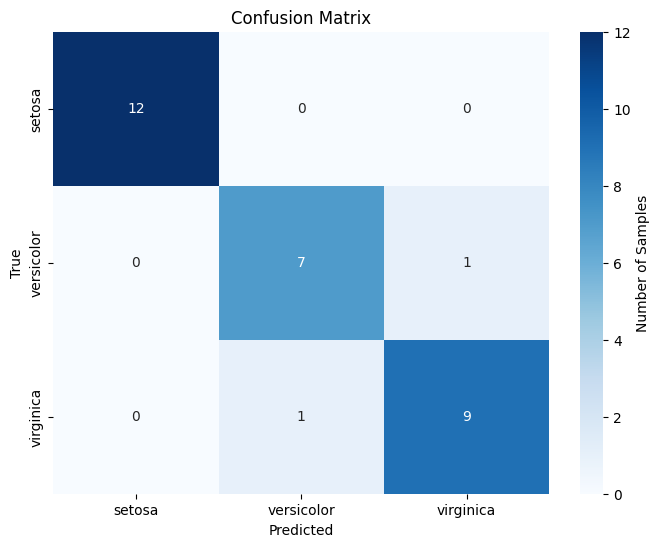

In [7]:
y_pred = grid_search.best_estimator_.predict(X_test)
class_names = iris.target_names

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Number of Samples'}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [8]:
report_dict = classification_report(
    y_test, y_pred,
    target_names=class_names,
    output_dict=True
)

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.88      0.88      0.88         8
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.92      0.92      0.92        30
weighted avg       0.93      0.93      0.93        30



## **Understanding evaluation metrics**
* **Learning curves:** Plot model performance against the size of the training dataset, showing how well the model learns as it is exposed to more examples, allowing analysts to identify issues like underfitting or overfitting.
* **Confusion matrix:** Provides a visual summary showing the counts of true positives (TPs), true negatives (TNs), false positives (FPs), and false negatives (FNs) across different classes.
* **Classification report:** Combines several metrics into a single table, including:
    * **Precision:** Accuracy of positive predictions. Calculated as $Precision=TP/(TP+FP)$.
    * **Recall:** Ability of a model to identify all relevant instances. Calculated as $Recall=TP/(TP+FN)$.
    * **F1-score:** The harmonic mean of precision and recall. Calculated as $F1=2\times (Precision\times Recall)/(Precision+Recall)$.
    * **Accuracy:** Ratio of total correct predictions out of all predictions made. Calculated as $Accuracy=(TP+TN)/(TP+FP+TN+FN)$.

## **Handling imbalanced datasets**
When dealing with imbalanced datasets where one class significantly outnumbers another, you need to use metrics such as precision-recall curves or ROC-AUC scores instead of accuracy alone. Techniques such as resampling can also help balance the dataset before training.